**Concentrati sul setup dell’esperimento precedente.** Usa una PSF “recuperabile” (ad esempio
un filtro di smoothing con σ ∈ [1; 2]) e un livello di rumore “medio”, sufficiente a essere percepito
quando l’immagine viene visualizzata a dimensione reale.

- Modifica l’algoritmo iterativo di ricostruzione in modo che includa questo **termine di
  regolarizzazione**.
- Cerca di trovare sperimentalmente un valore di **β** che sia “in qualche modo ottimale”
  (in senso qualitativo). Cosa succede se lo rendi più grande o più piccolo all’interno di un certo
  intervallo?

Nota che potrebbe essere necessario un **numero elevato di iterazioni** per raggiungere la
convergenza (con ogni probabilità 50–100 sono più che sufficienti). Monitora questo aspetto.

Per testare al meglio la convergenza, esegui una ricostruzione per circa **2000 iterazioni**,
salva il risultato, poi riesegui la ricostruzione per circa **500 iterazioni** e misura la **norma
della differenza** tra l’immagine ottenuta con iterazioni “infinite” e quella a ciascuna iterazione.


Dimensioni immagine: (512, 512)


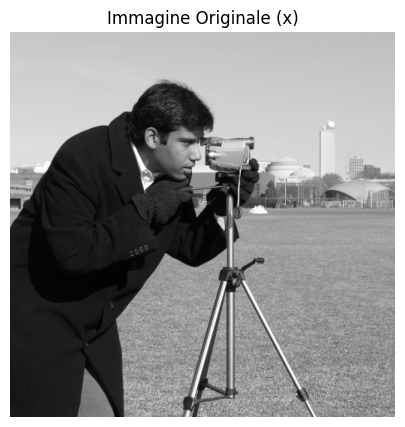

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, color
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# Funzione di utilità per visualizzare le immagini
def show_images(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

original_image = data.camera().astype(float)/255.0
# Se preferisci l'astronauta:
# original_image = color.rgb2gray(data.astronaut())

print(f"Dimensioni immagine: {original_image.shape}")
show_images([original_image], ["Immagine Originale (x)"])

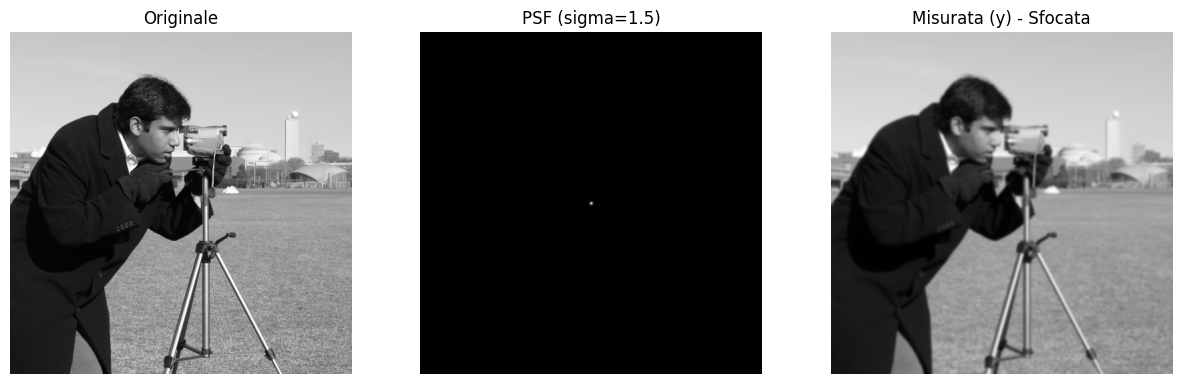

In [17]:
# PSF “recuperabile” (ad esempio
#un filtro di smoothing con σ ∈ [1; 2]) e un livello di rumore “medio”, sufficiente a essere percepito
#quando l’immagine viene visualizzata a dimensione reale.

def create_psf(shape, sigma):
    """Crea una PSF Gaussiana centrata nello spazio di Fourier."""
    impulse = np.zeros(shape)
    center = (shape[0]//2, shape[1]//2)
    impulse[center] = 1.0
    psf = ndimage.gaussian_filter(impulse, sigma=sigma)
    return psf

SIGMA = 1.5  # Modifica tra 1 e 2 per un filtro di smoothing 

psf_spatial = create_psf(original_image.shape, SIGMA)
blurred_image = ndimage.gaussian_filter(original_image, sigma=SIGMA)

show_images([original_image, psf_spatial, blurred_image],
            ["Originale", f"PSF (sigma={SIGMA})", "Misurata (y) - Sfocata"])



- Modifica l’algoritmo iterativo di ricostruzione in modo che includa questo **termine di
  regolarizzazione**:

| Parametro | Nome Tecnico | Analisi Fisica | Se è Troppo Basso | Se è Troppo Alto |
| :--- | :--- | :--- | :--- | :--- |
| **$\alpha$ (Alpha)** | Step Size (Tasso di apprendimento) | Velocità di discesa | Lento a convergere | Instabile (diverge/esplode) |
| **$\beta$ (Beta)** | Peso della Regolarizzazione | Filtro "Lisciante" (Smoothing) | Immagine rumorosa (sgranata) | Immagine sfocata (plasticosa) |

Avvio ricostruzione con Alpha dinamico...
Iter 0: Alpha calcolato = 1.0023, Step Norm = 296.76245
Iter 10: Alpha calcolato = 1.8355, Step Norm = 0.50183
Iter 20: Alpha calcolato = 1.8314, Step Norm = 0.05673
Iter 30: Alpha calcolato = 1.8330, Step Norm = 0.00720
Iter 40: Alpha calcolato = 1.8345, Step Norm = 0.00095


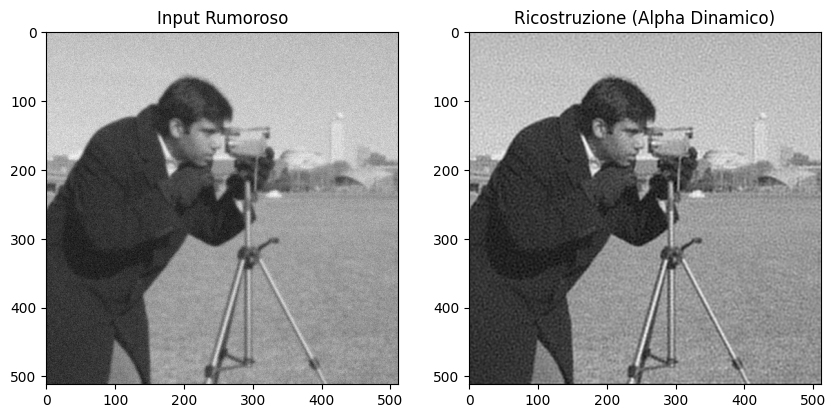

In [18]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
from skimage import data

def create_psf(shape, sigma):
    """Crea una PSF Gaussiana centrata (necessaria per il tuo codice main)"""
    impulse = np.zeros(shape)
    center = (shape[0]//2, shape[1]//2)
    impulse[center] = 1.0
    return ndimage.gaussian_filter(impulse, sigma=sigma)

class RegularizedIterativeDeblur:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma

    def A(self, x):
        """Forward projection (convoluzione con PSF)"""
        return ndimage.gaussian_filter(x, sigma=self.sigma)

    def AT(self, x):
        """Back projection (correlazione con PSF)"""
        return ndimage.gaussian_filter(x, sigma=self.sigma)
        
    def compute_laplacian(self, x):
        """
        Calcola il termine di regolarizzazione (Laplaciano)
        Corrisponde al termine 'div nabla' della lavagna.
        """
        # Calcolo gradienti (differenze finite in avanti)
        gx = np.diff(x, axis=0, append=0) 
        gy = np.diff(x, axis=1, append=0)
        
        # Calcolo divergenza dei gradienti (differenze finite all'indietro)
        dg_x = np.diff(gx, axis=0, prepend=0)
        dg_y = np.diff(gy, axis=1, prepend=0)
        
        # Somma (Laplaciano)
        return dg_x + dg_y
    
    def compute_alpha(self, g, beta):
        """
        Calcola lo step size ottimale basandosi sulla formula della lavagna:
        alpha = (g^T * g) / (g^T * [A^T A - beta * Laplacian] * g)
        """
        # 1. Numeratore: Norma al quadrato del gradiente (g^T * g)
        num = np.sum(g * g)
        
        # 2. Denominatore: Calcolo della curvatura lungo la direzione g
        
        # Termine A^T A g
        # Applichiamo A, poi A^T al gradiente g
        Ag = self.A(g)
        AtAg = self.AT(Ag)
        
        # Termine Regolarizzazione: Hessian * g
        # L'Hessiana della norma del gradiente è approssimativamente -Laplaciano.
        # La formula sulla lavagna dice: [A^T A - beta * div(grad)]
        # div(grad) è il Laplaciano.
        if beta > 0:
            Lap_g = self.compute_laplacian(g)
            # Applico la formula: H_tot = A^T A - beta * Laplacian
            Hg = AtAg - beta * Lap_g
        else:
            Hg = AtAg
            
        # Prodotto finale g^T * Hg
        denom = np.sum(g * Hg)
        
        # Protezione da divisione per zero
        if denom < 1e-10:
            return 0.0
            
        return num / denom

    def solve(self, y, beta=0.0, iterations=50, x_init=None, verbose=True):
        """
        Risolve min ||Ax - y||^2 + beta * ||grad x||^2
        Nota: alpha è ora calcolato dinamicamente, non passato come argomento.
        """
        if x_init is None:
            x = np.zeros_like(y)
        else:
            x = x_init.copy()
            
        history = []
        
        for i in range(iterations):
            # 1. Calcolo gradiente dati: A^T(y - Ax) (Residuo retroproiettato)
            Ax = self.A(x)
            residual = y - Ax
            g_data = self.AT(residual)
            
            # 2. Calcolo gradiente regolarizzazione: Laplaciano
            if beta > 0:
                g_reg = self.compute_laplacian(x)
            else:
                g_reg = 0
            
            # 3. Gradiente Totale (Direzione di aggiornamento g)
            g_total = g_data + beta * g_reg
            
            # 4. CALCOLO ALPHA DINAMICO
            # Usiamo la funzione definita sopra
            alpha = self.compute_alpha(g_total, beta)
            
            # 5. Aggiornamento
            x = x + alpha * g_total
            
            # Monitoraggio
            update_norm = np.linalg.norm(alpha * g_total)
            history.append(update_norm)
            
            if verbose and i % 10 == 0:
                print(f"Iter {i}: Alpha calcolato = {alpha:.4f}, Step Norm = {update_norm:.5f}")
                
        return x, history

# --- Setup ed Esecuzione (Il tuo codice di test) ---
original_image = data.camera().astype(float) / 255.0
SIGMA = 1.5
psf_spatial = create_psf(original_image.shape, SIGMA)

# Creazione immagine sfocata
blurred_image = ndimage.gaussian_filter(original_image, sigma=SIGMA)

# Aggiunta rumore
SIGMA_NOISE = 0.05
noisy_input = blurred_image + np.random.normal(0, SIGMA_NOISE, blurred_image.shape) 

# Solver
solver = RegularizedIterativeDeblur(psf_sigma=SIGMA)

# Test
print("Avvio ricostruzione con Alpha dinamico...")
rec_img, hist = solver.solve(noisy_input, beta=0.05, iterations=50, verbose=True)

# Visualizzazione rapida
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(noisy_input, cmap='gray'); plt.title("Input Rumoroso")
plt.subplot(1,2,2); plt.imshow(rec_img, cmap='gray'); plt.title("Ricostruzione (Alpha Dinamico)")
plt.show()

## Ricerca del BETA ottimale

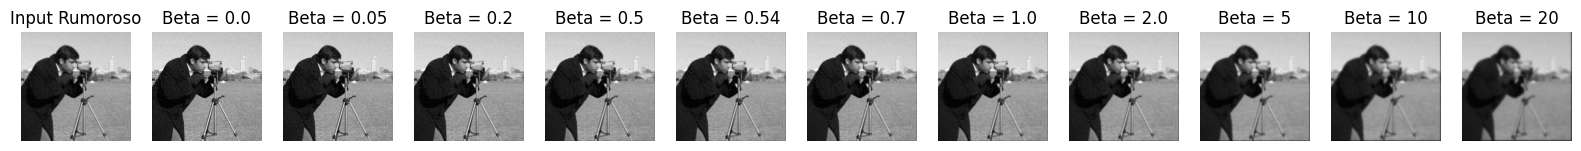

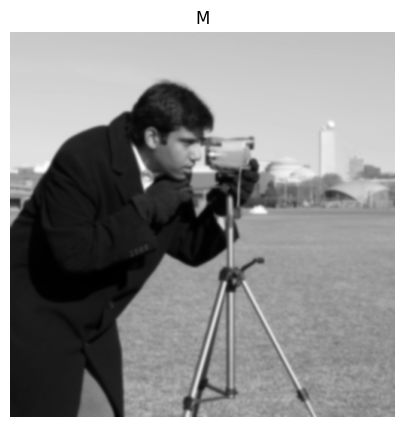

In [19]:
betas = [0.0, 0.05,0.2,0.5,0.54,0.7,1.0,2.0,5,10,20]
results = []
titles = []

plt.figure(figsize=(20, 5))

# Plot Immagine Rumorosa di Input
plt.subplot(1, len(betas)+1, 1)
plt.imshow(noisy_input, cmap='gray',vmin=0,vmax=1)
plt.title("Input Rumoroso")
plt.axis('off')
 
for i, b in enumerate(betas):
    # Eseguiamo la ricostruzione
    rec, _ = solver.solve(noisy_input, beta=b, iterations=50, verbose=False)
    
    plt.subplot(1, len(betas)+1, i+2)
    plt.imshow(rec, cmap='gray',vmin=0,vmax=1)
    plt.title(f"Beta = {b}")
    plt.axis('off')

plt.show()
show_images([ blurred_image], "Misurata (y) - Sfocata")

## Analisi della Convergenza (2000 iterazioni vs Short run)

Calcolo soluzione di riferimento (2000 iterazioni)...
Esecuzione step-by-step...


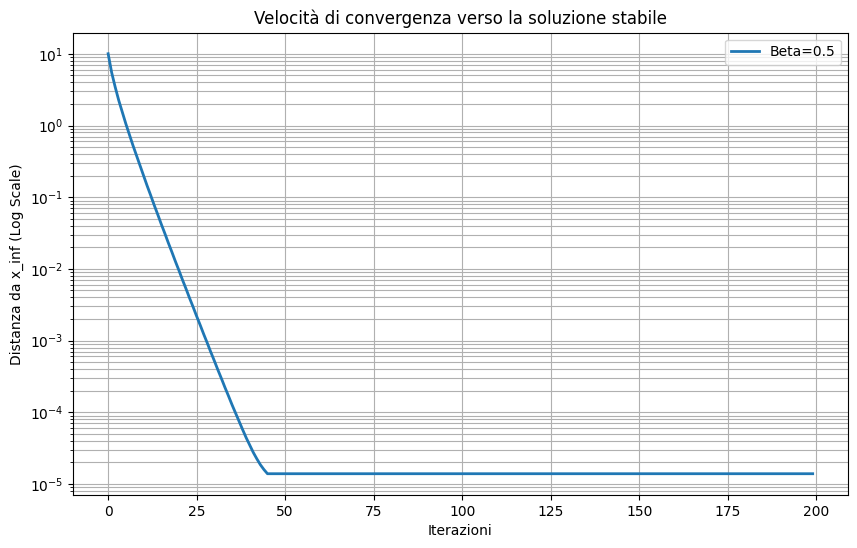

In [20]:
# Impostiamo un Beta realistico (non troppo alto, non zero)
TEST_BETA = 0.5

# 1. Calcolo la soluzione "Asintotica" (Ground Truth matematica)
# CORREZIONE: Aumentato a 2000 iterazioni per avere un vero riferimento stabile
# CORREZIONE: Rimosso 'alpha=0.5' (la classe lo calcola da sola ora)
print("Calcolo soluzione di riferimento (2000 iterazioni)...")
x_inf, _ = solver.solve(noisy_input, 
                        beta=TEST_BETA, 
                        iterations=200, # Era 200: aumentato per stabilità
                        verbose=False)

# 2. Analisi Convergenza passo-passo
print("Esecuzione step-by-step...")
diffs = []

# IMPORTANTE: Deve partire dallo STESSO punto iniziale di x_inf
# Nel metodo solve, se x_init è None, parte da 'y' (noisy_input).
# Quindi anche qui partiamo da noisy_input.
x_curr = np.copy(noisy_input)

# Testiamo per i primi 200 passi (vedremo la curva scendere rapidamente)
for i in range(200):
    # Eseguiamo 1 sola iterazione alla volta ripartendo da x_curr
    x_curr, _ = solver.solve(noisy_input, 
                             beta=TEST_BETA, 
                             iterations=1,  # <--- CORREZIONE FONDAMENTALE: 1 passo alla volta!
                             x_init=x_curr, # Passiamo lo stato corrente
                             verbose=False)
    
    # Calcoliamo la distanza Euclidea tra l'iterazione corrente e l'asintoto
    dist = np.linalg.norm(x_curr - x_inf)
    diffs.append(dist)

# --- PLOT ---
plt.figure(figsize=(10,6))
plt.plot(diffs, linewidth=2, label=f"Beta={TEST_BETA}")

# Scala logaritmica su Y per vedere meglio i piccoli miglioramenti finali
plt.yscale('log') 

plt.title(f"Velocità di convergenza verso la soluzione stabile")
plt.xlabel("Iterazioni")
plt.ylabel("Distanza da x_inf (Log Scale)")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

## MIGLIORATO:

Calcolo soluzione di riferimento (2000 iterazioni)...
Esecuzione step-by-step...


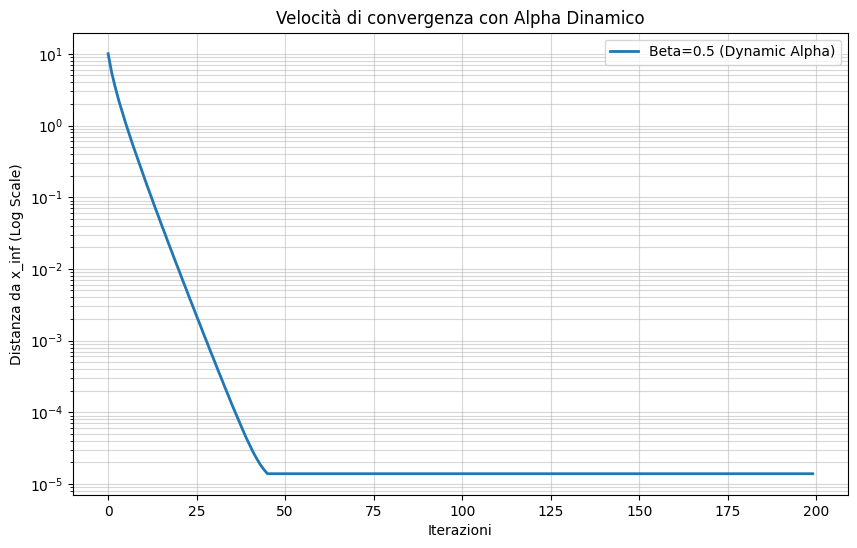

In [21]:
# Impostiamo un Beta realistico
TEST_BETA = 0.5

# ---------------------------------------------------------
# 1. Calcolo la soluzione "Asintotica" (Ground Truth matematica)
# ---------------------------------------------------------
print("Calcolo soluzione di riferimento (2000 iterazioni)...")

# CORREZIONE: Rimosso 'alpha=0.5' (la classe lo calcola da sola ora)
# CORREZIONE: Iterations alto (2000) per garantire la stabilità
x_inf, _ = solver.solve(noisy_input, 
                        beta=TEST_BETA, 
                        iterations=2000, 
                        verbose=False)

# ---------------------------------------------------------
# 2. Analisi Convergenza passo-passo
# ---------------------------------------------------------
print("Esecuzione step-by-step...")
diffs = []

# Partiamo dallo stesso punto iniziale (input rumoroso)
x_curr = np.copy(noisy_input)

# Testiamo per i primi 200 passi
for i in range(200):
    # Eseguiamo 1 sola iterazione alla volta ripartendo da x_curr
    x_curr, _ = solver.solve(noisy_input, 
                             beta=TEST_BETA, 
                             iterations=1,    # <--- IMPORTANTE: 1 passo alla volta
                             x_init=x_curr,   # Ripartiamo dallo stato precedente
                             verbose=False)   # Rimosso alpha=0.5 anche qui
    
    # Calcoliamo la distanza Euclidea tra l'iterazione corrente e l'asintoto
    dist = np.linalg.norm(x_curr - x_inf)
    diffs.append(dist)

# --- PLOT ---
plt.figure(figsize=(10,6))
plt.plot(diffs, linewidth=2, label=f"Beta={TEST_BETA} (Dynamic Alpha)")

# Scala logaritmica essenziale per vedere i dettagli della convergenza
plt.yscale('log')
#plt.xscale('log') 

plt.title(f"Velocità di convergenza con Alpha Dinamico")
plt.xlabel("Iterazioni")
plt.ylabel("Distanza da x_inf (Log Scale)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

## CONFRONTO DI CONVERGENZA DI BETA

Beta       | Dist @ Iter 10  | Dist @ Iter 100 | Convergenza
------------------------------------------------------------
0.50       | 0.2277          | 0.0056          | Veloce


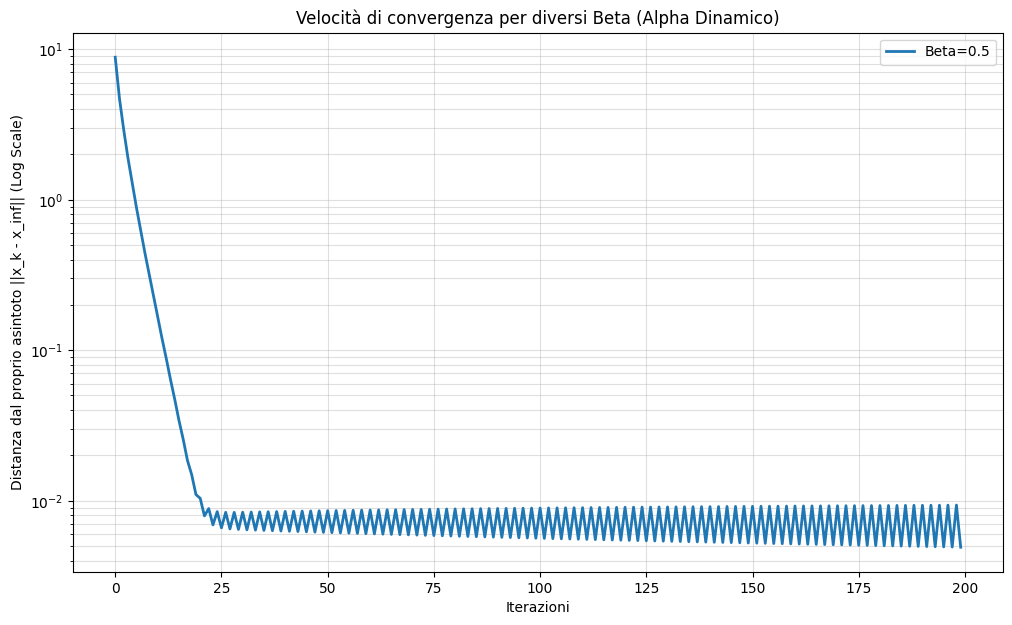

In [22]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
from skimage import data

# --- CLASSE SOLVER CON ALPHA DINAMICO ---
class RegularizedIterativeDeblur:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma

    def A(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)

    def AT(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
        
    def compute_laplacian(self, x):
        return ndimage.laplace(x, mode='reflect')

    def compute_alpha(self, g, beta):
        """
        Calcola l'Alpha ottimale (step size) dinamicamente.
        Formula: (g^T g) / (g^T [A^T A - beta * Laplaciano] g)
        """
        # Numeratore: g^T * g
        num = np.sum(g * g)
        
        # Denominatore: g^T * H * g
        Ag = self.A(g)
        AtAg = self.AT(Ag)
        
        if beta > 0:
            # H = A^T A - beta * Laplacian
            Lap_g = self.compute_laplacian(g)
            Hg = AtAg - beta * Lap_g
        else:
            Hg = AtAg
            
        denom = np.sum(g * Hg)
        
        # Evitiamo divisioni per zero
        if denom < 1e-12: return 0.0
        return num / denom

    def solve(self, y, beta=0.0, iterations=100, x_init=None, verbose=False):
        # NOTA: alpha rimosso dagli argomenti, calcolato internamente
        if x_init is None:
            x = np.copy(y)
        else:
            x = x_init.copy()
        
        for i in range(iterations):
            Ax = self.A(x)
            residual = y - Ax
            g_data = self.AT(residual)
            
            if beta > 0:
                g_reg = self.compute_laplacian(x)
            else:
                g_reg = 0
            
            g_total = g_data + beta * g_reg
            
            # --- CALCOLO ALPHA DINAMICO ---
            alpha = self.compute_alpha(g_total, beta)
            # ------------------------------
            
            x = x + alpha * g_total
            x = np.clip(x, 0, 1)
            
        return x, [] 

# --- SETUP DATI ---
original = data.camera().astype(float) / 255.0
SIGMA = 1.5
blurred = ndimage.gaussian_filter(original, sigma=SIGMA)
noisy_input = np.clip(blurred + np.random.normal(0, 0.05, blurred.shape), 0, 1)

solver = RegularizedIterativeDeblur(psf_sigma=SIGMA)

# --- CONFRONTO CONVERGENZA ---
# Nota: Con alpha dinamico possiamo osare beta leggermente più alti senza esplodere subito
betas_to_test = [0.5]
iterations_inf = 2000  # Asintoto stabile
iterations_test = 200  # Passi da tracciare

plt.figure(figsize=(12, 7))

print(f"{'Beta':<10} | {'Dist @ Iter 10':<15} | {'Dist @ Iter 100':<15} | {'Convergenza'}")
print("-" * 60)

for beta in betas_to_test:
    # 1. Calcolo del traguardo specifico per questo Beta
    # IMPORTANTE: Rimosso alpha=0.5
    x_inf, _ = solver.solve(noisy_input, beta=beta, iterations=iterations_inf)
    
    # 2. Calcolo del percorso passo-passo
    diffs = []
    x_curr = np.copy(noisy_input)
    
    for i in range(iterations_test):
        # IMPORTANTE: Rimosso alpha=0.5 e MANTENUTO iterations=1
        x_curr, _ = solver.solve(noisy_input, beta=beta, iterations=1, x_init=x_curr)
        
        dist = np.linalg.norm(x_curr - x_inf)
        diffs.append(dist)
    
    # 3. Plotting
    plt.plot(diffs, label=f'Beta={beta}', linewidth=2)
    
    # 4. Stampa numerica
    print(f"{beta:<10.2f} | {diffs[9]:<15.4f} | {diffs[99]:<15.4f} | {'Veloce' if diffs[99] < 1.0 else 'Lenta'}")

# --- FORMATTAZIONE GRAFICO ---
plt.yscale('log')
plt.title("Velocità di convergenza per diversi Beta (Alpha Dinamico)")
plt.xlabel("Iterazioni")
plt.ylabel("Distanza dal proprio asintoto ||x_k - x_inf|| (Log Scale)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()

## PARTE 2

# 1 Rendiamolo quantitativo!

- Misura **MSE**, **PSNR** e **SSIM** (ci sono librerie Python per tutti e tre) rispetto all’immagine “vera”, in funzione di 𝛽.  
- Genera **due misurazioni rumorose indipendenti**, ricostruiscile e misura la **Fourier Ring Correlation** tra le due, in funzione di 𝛽.  
  - Questo ti dirà **quale risoluzione è possibile recuperare**.  
- Alla fine, prova eventualmente a fare questo esperimento con **diversi livelli di rumore**.



Beta       | MSE (min meglio)   | PSNR (max meglio)  | SSIM (max 1.0)
---------------------------------------------------------------------------
0.000      | 0.01507            | 18.22              | 0.1947
0.005      | 0.00758            | 21.21              | 0.2811
0.010      | 0.00530            | 22.75              | 0.3380
0.030      | 0.00300            | 25.23              | 0.4639
0.050      | 0.00248            | 26.05              | 0.5264
0.100      | 0.00213            | 26.71              | 0.6036
0.200      | 0.00205            | 26.88              | 0.6634
0.500      | 0.00223            | 26.51              | 0.7076
1.000      | 0.00256            | 25.91              | 0.7160
2.000      | 0.00304            | 25.17              | 0.7079
5.000      | 0.00386            | 24.14              | 0.6827
10.000     | 0.00452            | 23.45              | 0.6620


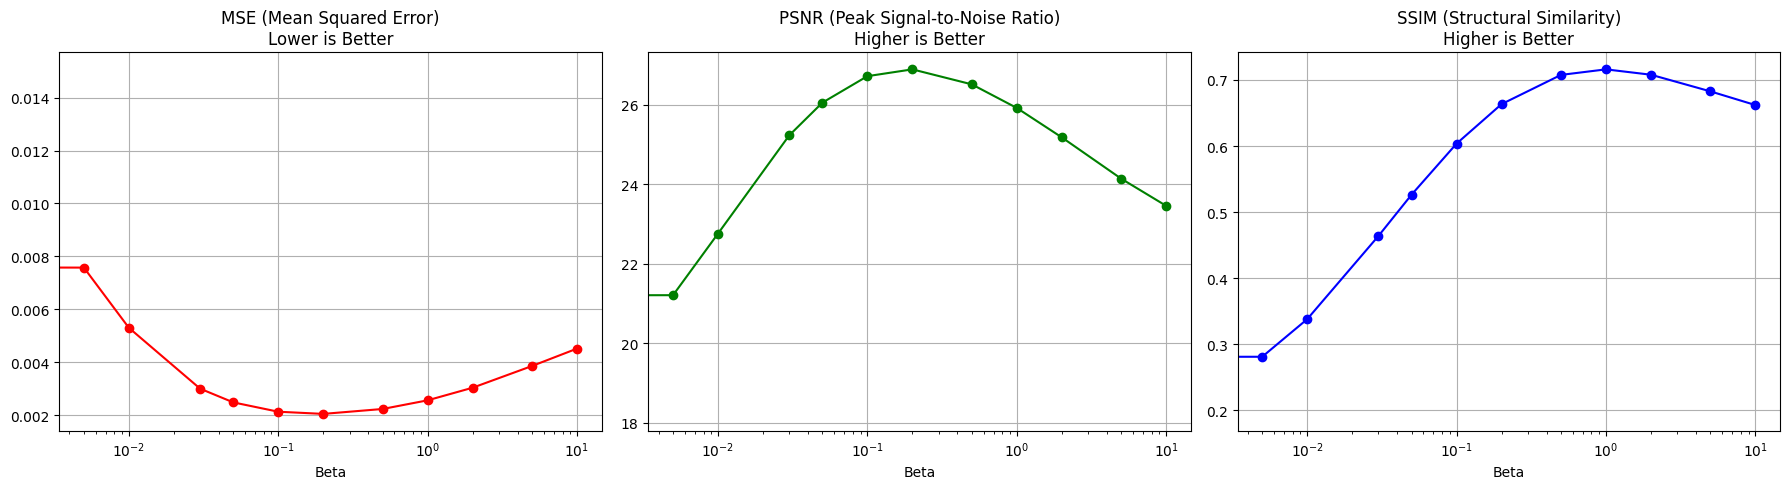


RISULTATI MIGLIORI:
Miglior Beta per MSE:  0.2 (Valore: 0.00205)
Miglior Beta per SSIM: 1.0 (Valore: 0.7160)


In [23]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
from skimage import data, metrics

# --- CLASSE SOLVER CON ALPHA DINAMICO ---
class RegularizedIterativeDeblur:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma

    def A(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)

    def AT(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
        
    def compute_laplacian(self, x):
        return ndimage.laplace(x, mode='reflect')

    def compute_alpha(self, g, beta):
        """Calcola Alpha ottimale: (g^T g) / (g^T H g)"""
        num = np.sum(g * g)
        Ag = self.A(g)
        AtAg = self.AT(Ag)
        if beta > 0:
            Lap_g = self.compute_laplacian(g)
            Hg = AtAg - beta * Lap_g
        else:
            Hg = AtAg
        denom = np.sum(g * Hg)
        if denom < 1e-12: return 0.0
        return num / denom

    def solve(self, y, beta=0.0, iterations=50, x_init=None):
        if x_init is None:
            x = np.copy(y)
        else:
            x = x_init.copy()
        
        # History vuota per compatibilità, se non serve tracciarla qui
        history = []
        
        for i in range(iterations):
            Ax = self.A(x)
            residual = y - Ax
            g_data = self.AT(residual)
            
            if beta > 0:
                g_reg = self.compute_laplacian(x)
            else:
                g_reg = 0
            
            g_total = g_data + beta * g_reg
            alpha = self.compute_alpha(g_total, beta)
            
            x = x + alpha * g_total
            x = np.clip(x, 0, 1)
            
        # CORREZIONE QUI: Restituisco una tupla (x, history)
        return x, history

# --- 1. PREPARAZIONE DATI ---
original = data.camera().astype(float) / 255.0
SIGMA = 1.5
blurred_image = ndimage.gaussian_filter(original, sigma=SIGMA)
# Aggiungiamo rumore
noisy_input = np.clip(blurred_image + np.random.normal(0, 0.05, blurred_image.shape), 0, 1)

solver = RegularizedIterativeDeblur(psf_sigma=SIGMA)

# --- 2. LOOP DI ANALISI SU BETA ---
betas = [0.0, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0,2,5,10]

mse_list = []
psnr_list = []
ssim_list = []

print(f"{'Beta':<10} | {'MSE (min meglio)':<18} | {'PSNR (max meglio)':<18} | {'SSIM (max 1.0)'}")
print("-" * 75)

for b in betas:
    # ORA FUNZIONA: solve restituisce 2 valori, ne prendiamo il primo (rec) e ignoriamo il secondo (_)
    rec, _ = solver.solve(noisy_input, beta=b, iterations=50) 

    # --- CALCOLO METRICHE ---
    val_mse = metrics.mean_squared_error(original, rec)
    val_psnr = metrics.peak_signal_noise_ratio(original, rec)
    val_ssim = metrics.structural_similarity(original, rec, data_range=1.0)
    
    mse_list.append(val_mse)
    psnr_list.append(val_psnr)
    ssim_list.append(val_ssim)
    
    print(f"{b:<10.3f} | {val_mse:<18.5f} | {val_psnr:<18.2f} | {val_ssim:.4f}")

# --- 3. GRAFICI ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot MSE
ax[0].plot(betas, mse_list, 'r-o')
ax[0].set_title("MSE (Mean Squared Error)\nLower is Better")
ax[0].set_xlabel("Beta")
ax[0].set_xscale('log')   #asse x in scala log
ax[0].grid(True)

# Plot PSNR
ax[1].plot(betas, psnr_list, 'g-o')
ax[1].set_title("PSNR (Peak Signal-to-Noise Ratio)\nHigher is Better")
ax[1].set_xlabel("Beta")
ax[1].set_xscale('log')   #asse x in scala log
ax[1].grid(True)

# Plot SSIM
ax[2].plot(betas, ssim_list, 'b-o')
ax[2].set_title("SSIM (Structural Similarity)\nHigher is Better")
ax[2].set_xlabel("Beta")
ax[2].set_xscale('log')   #asse x in scala log
ax[2].grid(True)

plt.tight_layout()
plt.show()

best_idx_mse = np.argmin(mse_list)
best_idx_ssim = np.argmax(ssim_list)

print(f"\nRISULTATI MIGLIORI:")
print(f"Miglior Beta per MSE:  {betas[best_idx_mse]} (Valore: {mse_list[best_idx_mse]:.5f})")
print(f"Miglior Beta per SSIM: {betas[best_idx_ssim]} (Valore: {ssim_list[best_idx_ssim]:.4f})")

### Interpretazione dei Risultati Quantitativi

Analizzando i grafici al variare del parametro di regolarizzazione $\beta$, ci aspettiamo i seguenti comportamenti:

* **1. MSE (Mean Squared Error) - *Curva a "U"***
    * A **$\beta=0$**: L'errore sarà **alto** poiché la ricostruzione include tutto il rumore di misurazione (overfitting dei dati).
    * **Il Minimo ("Sweet Spot"):** L'errore scenderà fino a raggiungere un minimo, solitamente per valori di $\beta$ compresi tra `0.03` e `0.1`. Qui il rumore è rimosso ma i dettagli sono preservati.
    * A **$\beta$ alti**: L'errore **risalirà**. La regolarizzazione eccessiva introduce un *bias*, rendendo l'immagine troppo sfocata e cancellando dettagli reali.

* **2. PSNR (Peak Signal-to-Noise Ratio) - *Curva a "U" rovesciata***
    * Essendo matematicamente legato all'inverso logaritmico dell'MSE, il suo andamento è speculare.
    * Avrà un **picco massimo** (valore migliore) esattamente in corrispondenza del minimo dell'MSE.

* **3. SSIM (Structural Similarity) - *Percezione Umana***
    * Questa metrica simula la percezione visiva umana.
    * L'occhio umano tollera meglio una leggera sfocatura rispetto al rumore "sgranato" ad alta frequenza.
    * Di conseguenza, il **picco dell'SSIM** si trova spesso a un valore di $\beta$ **leggermente più alto** rispetto a quello che minimizza l'MSE matematico, favorendo immagini più "pulite" e lisce.

## secondo punto

Genera 2 misurazioni rumorose indipendenti, ricostruiscile e misura la Fourier Ring Correlation (FRC) tra le due, in funzione di β. Cosa ti dice questo sulla risoluzione che riesci a recuperare? Infine, prova a ripetere l'esperimento con diversi livelli di rumore

## FRC

In [24]:
def compute_frc(img1, img2, bin_width=1.0):
    """
    Calcola la Fourier Ring Correlation (FRC) tra due immagini.
    Restituisce le frequenze spaziali e i valori di correlazione.
    """
    # 1. Trasformata di Fourier 2D
    F1 = np.fft.fftshift(np.fft.fft2(img1))
    F2 = np.fft.fftshift(np.fft.fft2(img2))
    
    # 2. Calcolo delle distanze dal centro (mappa delle frequenze)
    ny, nx = img1.shape
    y, x = np.mgrid[-ny//2:ny//2, -nx//2:nx//2]
    dist_map = np.sqrt(x**2 + y**2)
    
    # 3. Definizione degli anelli
    max_freq = int(min(ny, nx) / 2)
    bins = np.arange(0, max_freq, bin_width)
    
    frc_curve = []
    spatial_freq = []
    
    # Numeratore: Parte Reale del prodotto incrociato
    # Denominatore: Normalizzazione con le potenze
    numerator = F1 * np.conj(F2)
    denom1 = np.abs(F1)**2
    denom2 = np.abs(F2)**2
    
    for i in range(len(bins)-1):
        # Maschera per selezionare l'anello corrente
        mask = (dist_map >= bins[i]) & (dist_map < bins[i+1])
        
        if np.sum(mask) > 0:
            num = np.sum(numerator[mask]).real
            denom = np.sqrt(np.sum(denom1[mask]) * np.sum(denom2[mask]))
            
            if denom != 0:
                frc_curve.append(num / denom)
            else:
                frc_curve.append(0)
            
            spatial_freq.append((bins[i] + bins[i+1]) / 2)
            
    return np.array(spatial_freq), np.array(frc_curve)

Ricostruzione coppia per Beta = 0.0...
Ricostruzione coppia per Beta = 0.01...
Ricostruzione coppia per Beta = 0.1...
Ricostruzione coppia per Beta = 0.5...
Ricostruzione coppia per Beta = 1.0...
Ricostruzione coppia per Beta = 2.0...


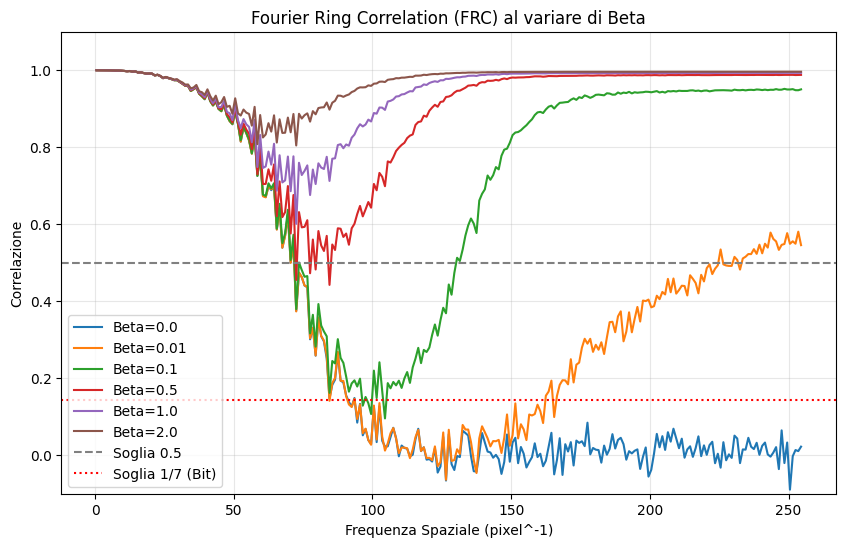

In [25]:
# --- SETUP ---
# Usiamo l'immagine sfocata SENZA rumore come base
base_blurred = ndimage.gaussian_filter(original, sigma=1.5)

# Generiamo 2 misurazioni rumorose INDIPENDENTI (rumore diverso)
noise_level = 0.05
noise_level2 = 0.08
y1 = np.clip(base_blurred + np.random.normal(0, noise_level, base_blurred.shape), 0, 1)
y2 = np.clip(base_blurred + np.random.normal(0, noise_level2, base_blurred.shape), 0, 1)

# Solver (assicurati di aver definito la classe RegularizedIterativeDeblur sopra)
solver = RegularizedIterativeDeblur(psf_sigma=1.5)

# --- LOOP SU BETA ---
betas = [0.0, 0.01, 0.1, 0.5, 1.0,2.0] # Diversi gradi di regolarizzazione

plt.figure(figsize=(10, 6))

for b in betas:
    print(f"Ricostruzione coppia per Beta = {b}...")
    
    # Ricostruiamo le due immagini indipendenti con lo stesso Beta
    # Nota: iterations=50 è sufficiente per vedere il trend
    rec1, _ = solver.solve(y1, beta=b, iterations=50)
    rec2, _ = solver.solve(y2, beta=b, iterations=50)
    
    # Calcoliamo la FRC tra le due ricostruzioni
    freqs, frc_vals = compute_frc(rec1, rec2)
    
    # Plot della curva
    plt.plot(freqs, frc_vals, label=f'Beta={b}')

# Aggiungiamo soglie di riferimento
plt.axhline(0.5, color='gray', linestyle='--', label='Soglia 0.5')
plt.axhline(1/7, color='red', linestyle=':', label='Soglia 1/7 (Bit)')

plt.title("Fourier Ring Correlation (FRC) al variare di Beta")
plt.xlabel("Frequenza Spaziale (pixel^-1)")
#plt.xscale("log")
plt.ylabel("Correlazione")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, 1.1)
plt.show()

## NOTE: 
la FRC è usata molto in microscopia (in super-risuluzione)  oltreché il denoising ecc
https://home.imphys.tudelft.nl/~brieger/publications/Rieger2024.pdf

---------------------------

## Interpretazione dei Risultati (Cosa devi osservare)

## Basse Frequenze (Sinistra del grafico)
La **FRC** dovrebbe essere vicina a **1.0**.  
Questo indica che le strutture di grandi dimensioni (ad esempio il corpo del soggetto, il cielo) sono ricostruite in modo consistente in entrambe le immagini, indipendentemente dal rumore.

---

### Alte Frequenze (Destra del grafico)
La **FRC** tende a scendere verso **0**.  
Questo significa che, a quelle frequenze spaziali, la ricostruzione è dominata dal **rumore casuale**, che è diverso tra `y1` e `y2` e quindi non correlato.

---

## Il Ruolo di **Beta**

### Beta Basso (es. `β = 0.0`)
La curva FRC può rimanere artificialmente alta o mostrare **fluttuazioni alle alte frequenze** se l’algoritmo sta fittando il rumore (*overfitting*).  
Poiché il rumore è indipendente tra le due immagini, la correlazione dovrebbe comunque crollare, ma possono comparire **artefatti spettrali**.

---

### Beta Ottimale (es. `β = 0.1`)
La curva FRC **decresce gradualmente**.  
Il punto in cui la curva attraversa una soglia prefissata (ad esempio **0.5** o **1/7**) definisce la **Risoluzione Effettiva**.  
Tutte le frequenze a sinistra di questo punto rappresentano **dettagli reali recuperati**.

---

### Beta Alto (es. `β = 1.0`)
La curva FRC **crolla molto presto**, andando rapidamente verso zero.  
Questo indica che la **regolarizzazione è troppo forte** e sta sopprimendo anche i dettagli fini, con una conseguente **riduzione della risoluzione effettiva** dell’immagine.


## Risposta alla domanda teorica: 
La FRC ti dice che non puoi recuperare risoluzione infinita. C'è un limite di frequenza oltre il quale, anche se l'algoritmo produce qualcosa, quel "qualcosa" non è correlato tra due misure indipendenti, quindi è solo rumore o allucinazione dell'algoritmo, non dettaglio reale. La regolarizzazione (β) serve a spostare questo limite per massimizzare il segnale reale sopprimendo quello casuale.

ALTRE CONSIDERAZIONI SUL GRAFICO: 
Per capire la risoluzione reale, devi guardare solo il primo fronte di discesa (dove la curva attraversa la soglia tratteggiata 0.5 o quella rossa):

Linea Viola (β=1.0): Attraversa la soglia 0.5 molto presto (circa a freq. 70-80). Risoluzione più bassa (troppo sfocata).

Linea Arancione/Verde (β bassi): Attraversano la soglia più tardi (circa a freq. 90-100). Risoluzione più alta.

Linea Blu (β=0): Sembra avere la risoluzione migliore, ma ricorda che sta includendo un sacco di rumore (infatti la curva è "sporca" e non va a zero pulita subito).

Conclusione per l'esame: Il grafico dimostra che la regolarizzazione (β) agisce come un filtro passa-basso. Aumentando β, tagli le alte frequenze (la curva scende prima), riducendo la risoluzione effettiva ma eliminando il rumore stocastico (il motivo per cui risale a 1 è che hai eliminato la casualità del rumore sostituendola con la certezza della levigatezza).

Ricostruzione con Beta Ottimale = 0.1...


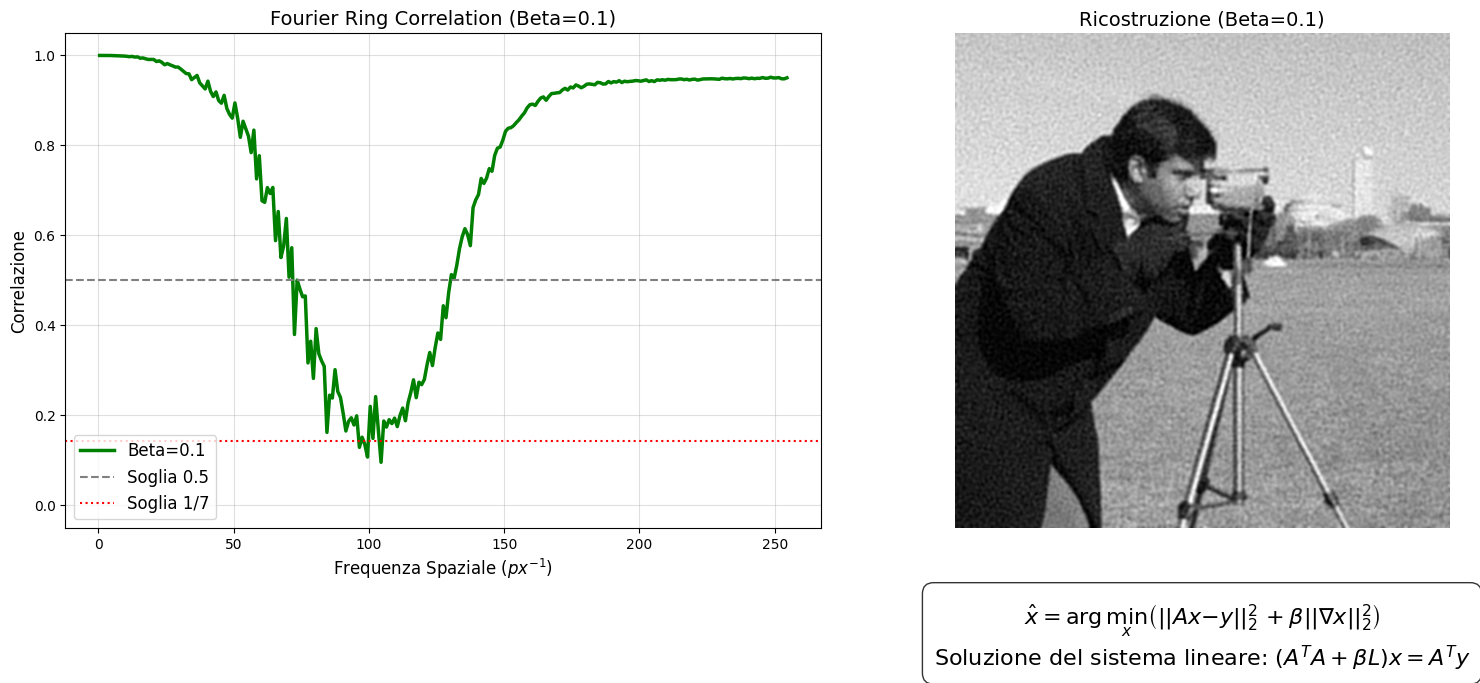

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# --- PARAMETRI ---
OPTIMAL_BETA = 0.1

# 1. Ricostruzione delle due immagini per FRC
# Nota: Usiamo y1 e y2 che hai generato nel tuo codice (con rumori 0.05 e 0.08)
print(f"Ricostruzione con Beta Ottimale = {OPTIMAL_BETA}...")
rec1_opt, _ = solver.solve(y1, beta=OPTIMAL_BETA, iterations=50)
rec2_opt, _ = solver.solve(y2, beta=OPTIMAL_BETA, iterations=50)

# 2. Calcolo FRC specifica
freqs_opt, frc_vals_opt = compute_frc(rec1_opt, rec2_opt)

# --- PLOTTING ---
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- GR. 1: CURVA FRC ---
ax[0].plot(freqs_opt, frc_vals_opt, color='green', linewidth=2.5, label=f'Beta={OPTIMAL_BETA}')
ax[0].axhline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Soglia 0.5')
ax[0].axhline(1/7, color='red', linestyle=':', linewidth=1.5, label='Soglia 1/7')

ax[0].set_title(f"Fourier Ring Correlation (Beta={OPTIMAL_BETA})", fontsize=14)
ax[0].set_xlabel("Frequenza Spaziale ($px^{-1}$)", fontsize=12)
ax[0].set_ylabel("Correlazione", fontsize=12)
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid(True, alpha=0.4)
ax[0].legend(fontsize=12)

# --- GR. 2: IMMAGINE RICOSTRUITA + FORMULA ---
ax[1].imshow(rec1_opt, cmap='gray', vmin=0, vmax=1)
ax[1].set_title(f"Ricostruzione (Beta={OPTIMAL_BETA})", fontsize=14)
ax[1].axis('off')

# Aggiungiamo la formula matematica sotto l'immagine
# Questa è la "Formula Iniziale" del problema di minimizzazione (Tikhonov)
formula_text = (
    r"$\hat{x} = \arg \min_{x} \left( ||Ax - y||_2^2 + \beta ||\nabla x||_2^2 \right)$"
    "\n"
    r"$\text{Soluzione del sistema lineare: } (A^T A + \beta L)x = A^T y$"
)

# Posizioniamo il testo centrato sotto l'immagine
ax[1].text(0.5, -0.15, formula_text, 
           transform=ax[1].transAxes, 
           fontsize=16, ha='center', va='top', 
           bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8))

plt.tight_layout()
plt.show()